# Part_1_Gradient_x_Input

### PART 1: GRADIENT × INPUT

In [ ]:
# PART 1 — Gradient × Input
# This notebook explains which tokens your CamemBERT-based emotion classifier is relying on using Gradient × Input.

from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# Load model and tokenizer from local fine-tuned CamemBERT directory
model_path = "./camembert_model_6"
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)
model.eval()

# 18 handpicked French sentences (3 for each emotion)
sentences_by_emotion = {
    "happiness": [
        "Il est super!Je veux dire que nous passons un si bon moment ensemble!Il est tellement drôle et tellement doux, et je ne suis pas du tout attiré par lui !!",
        "Les Recaptchas d'aujourd'hui étaient amusants.",
        "Oh, c'est super."
    ],
    "sadness": [
        "Je à peux tout simplement pas comprendre ce vaudou ne capuche d'un autre monde.",
        "Ces moments heureux me manquent.",
        "Je juste triste quand je vois des gens commenter des articles et des vidéos lui qu'ils pensent qu'il sur la."
    ],
    "anger": [
        "Les mecs nus dans le magazine Playgirl ! C'était comme le magazine Playboy, mais avec des hommes nus.",
        "Si ce genre de gars sont votre seule option, vous pourriez être mieux hors célibataire…",
        "Je veux récupérer mon putain de gâteau."
    ],
    "surprise": [
        "Je ne peux pas croire que cela vient d'arriver !",
        "Dans un autre environnement ?",
        "Comment ça s'est passé en première page ?"
    ],
    "fear": [
        "Euhhh, je ne pense pas que tu vas aimer ça.",
        "Aw, peux-tu dire ça?Je ne peux même pas demander Marcel de manger tapis de bain. vais-je élever un enfant?",
        "J'ai peur de devoir suivre ce qu'il a dit il y a une heure."
    ],
    "disgust": [
        "Comment quelqu'un peut-il supporter ça ?",
        "La Ligue veut qu'une équipe de DE LA travaille enfin si mal.",
        "Je me sens malade rien qu'en regardant ça."
    ]
}


### Gradient × Input Method

In [4]:
# Function: Compute token relevance using Gradient × Input
def gradient_x_input(model, inputs):
    inputs_embeds = model.get_input_embeddings()(inputs.input_ids)
    inputs_embeds = inputs_embeds.clone().detach().requires_grad_(True)

    outputs = model(inputs_embeds=inputs_embeds, attention_mask=inputs.attention_mask)
    outputs.logits[:, outputs.logits.argmax()].backward()

    if inputs_embeds.grad is None:
        raise RuntimeError("No gradients computed! Check that embeddings are passed correctly.")
    
    return inputs_embeds.grad * inputs_embeds

### Visualize & Save Results

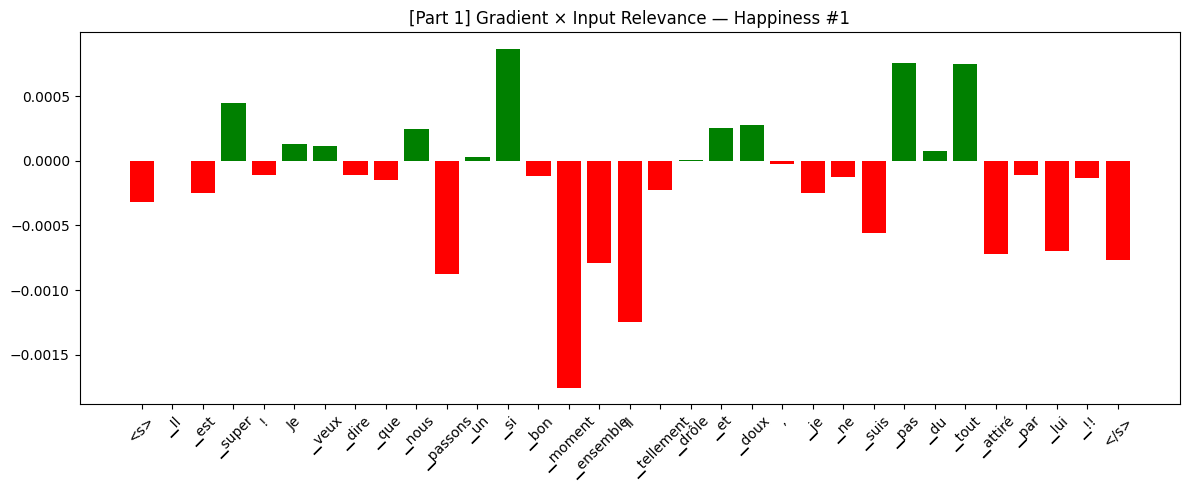

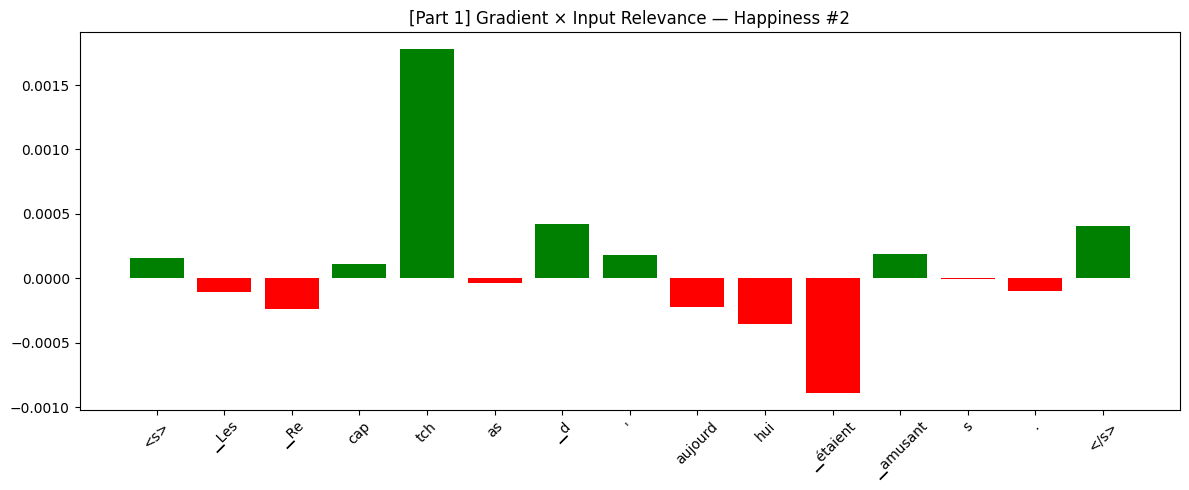

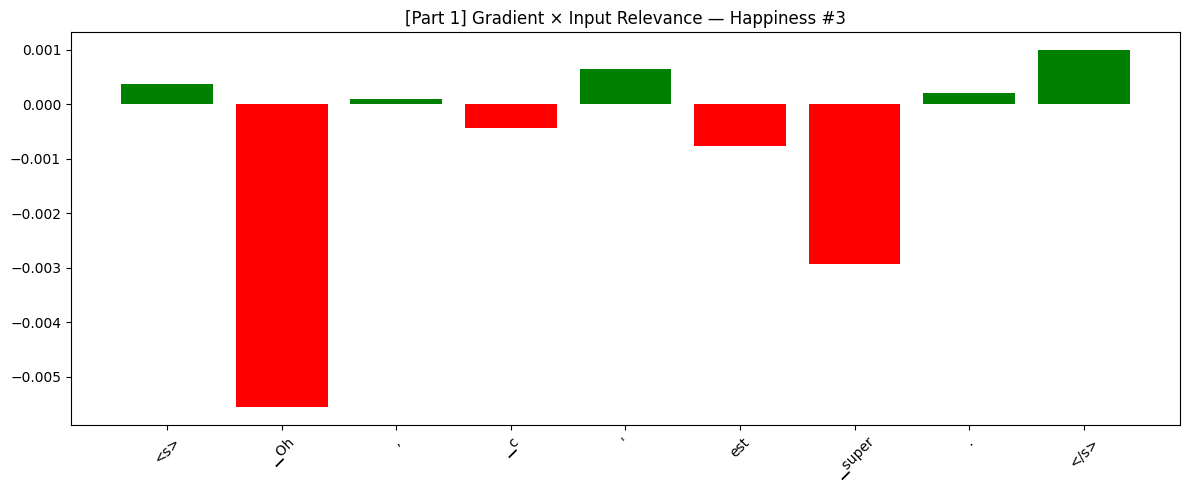

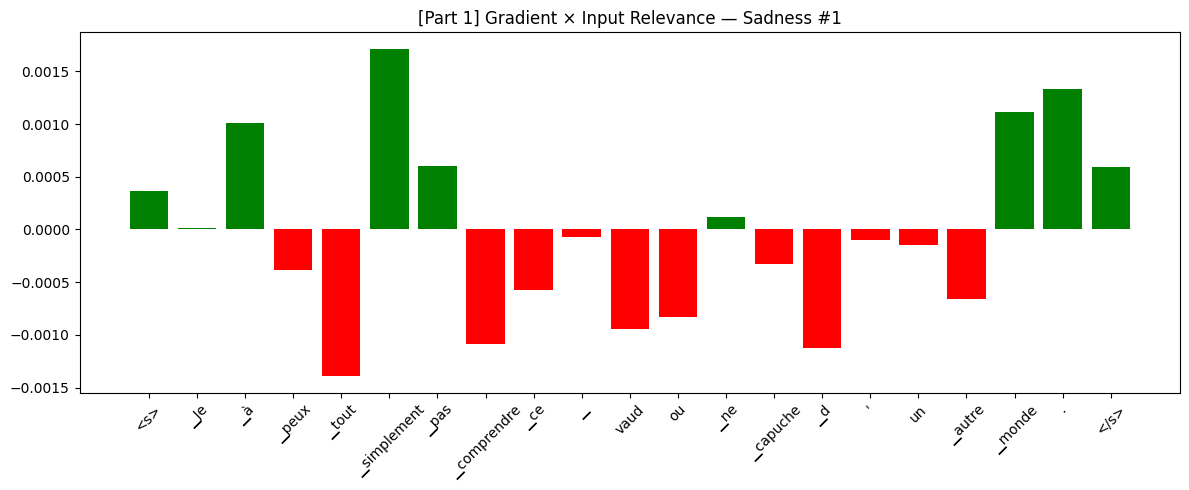

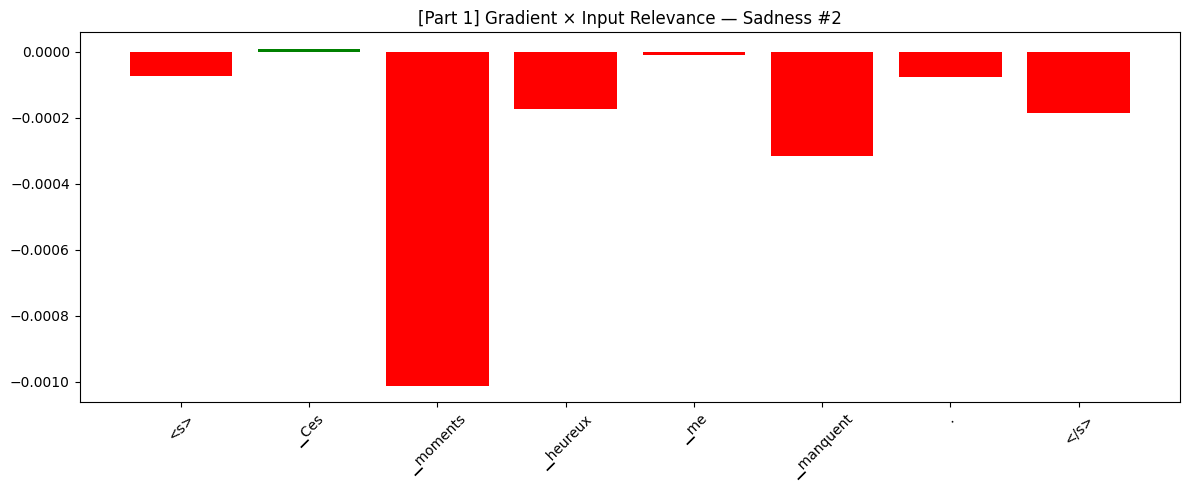

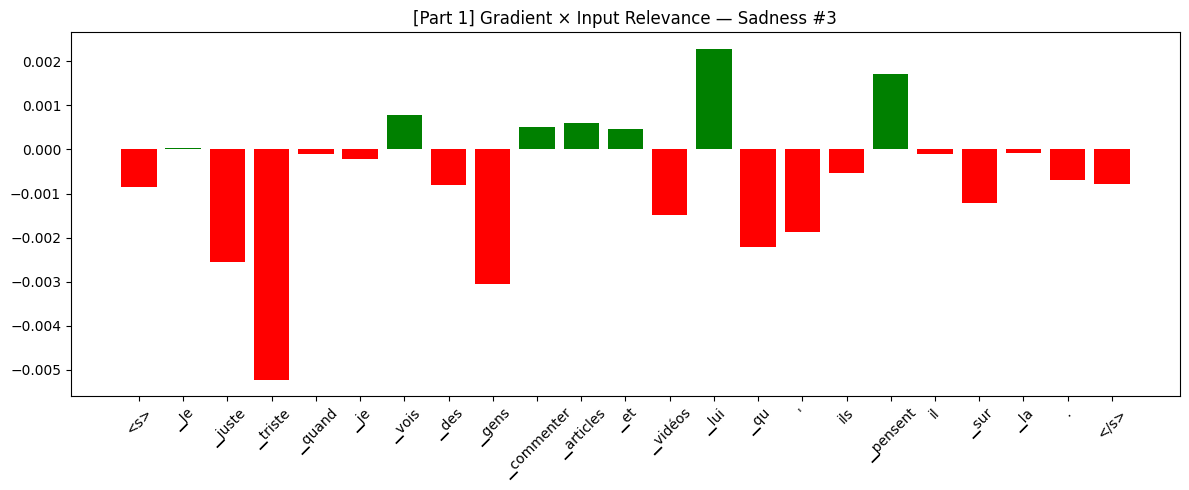

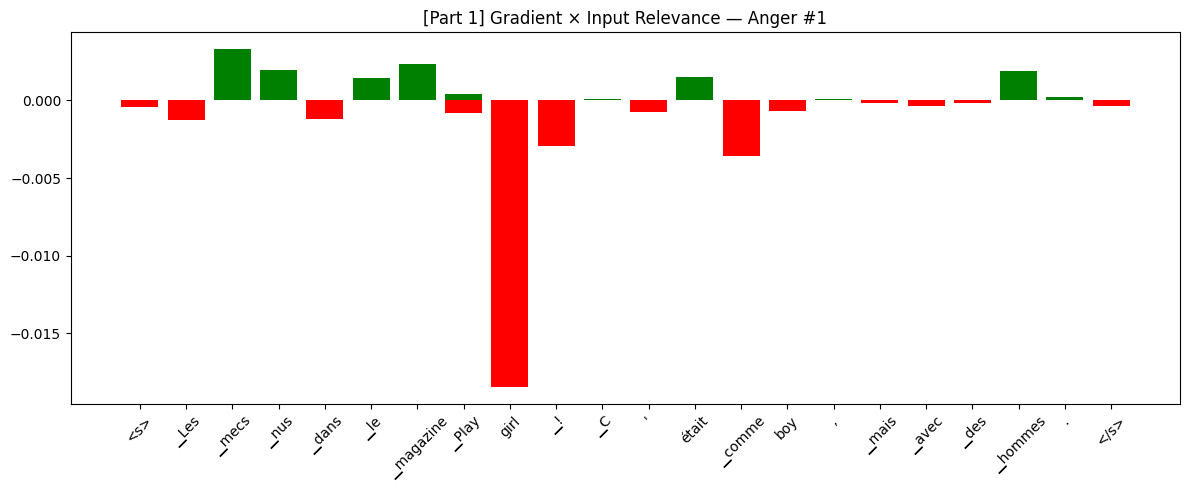

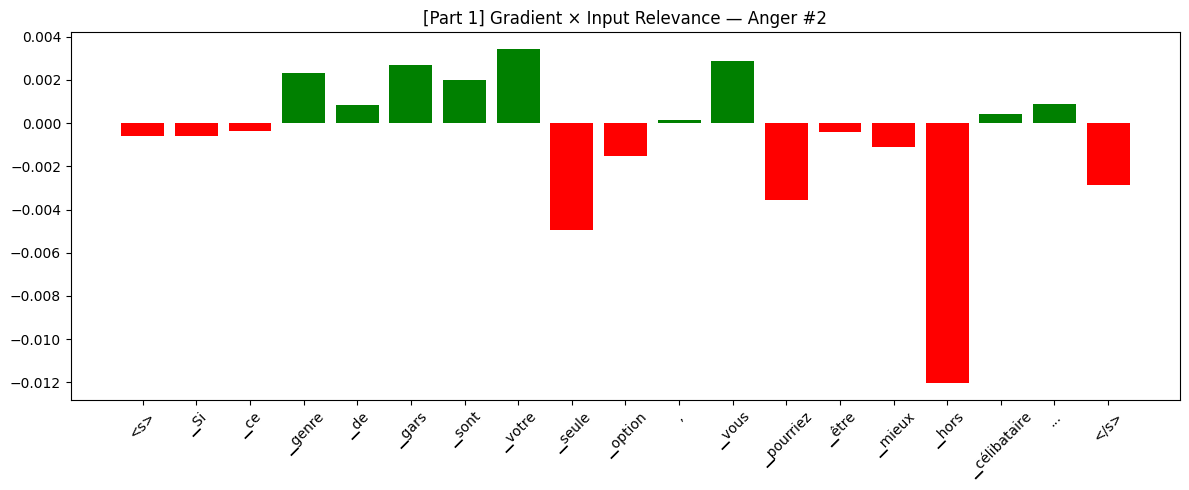

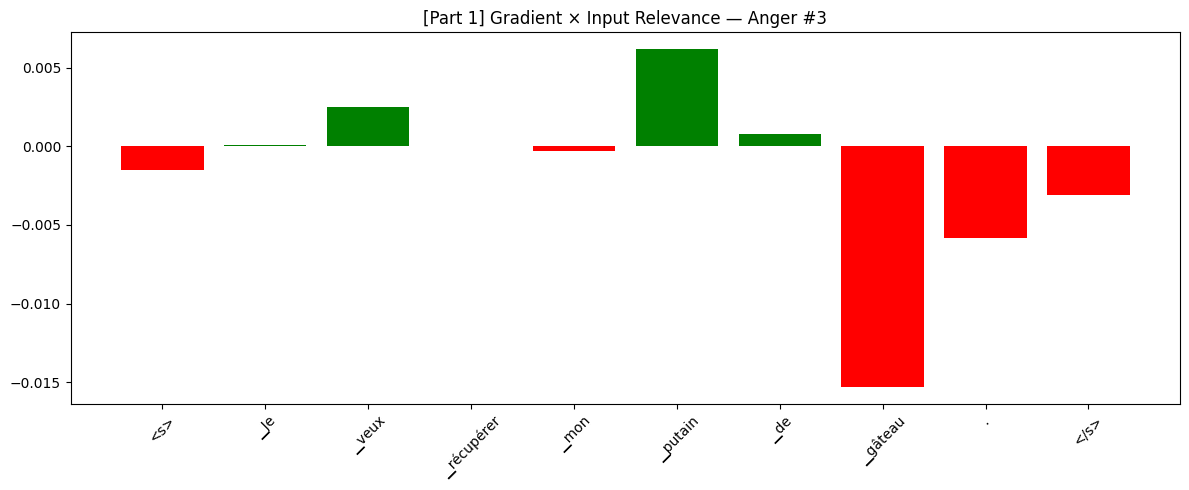

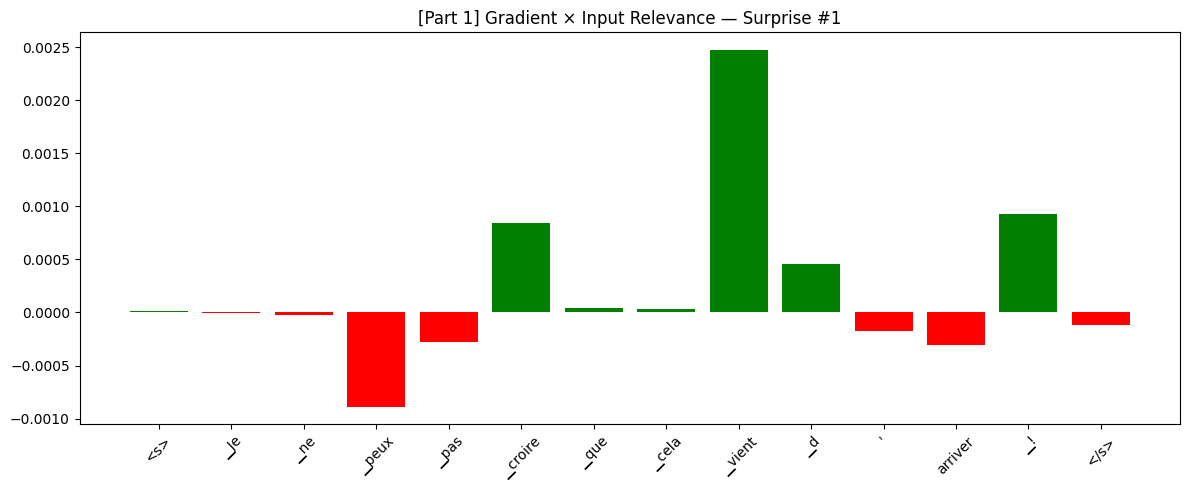

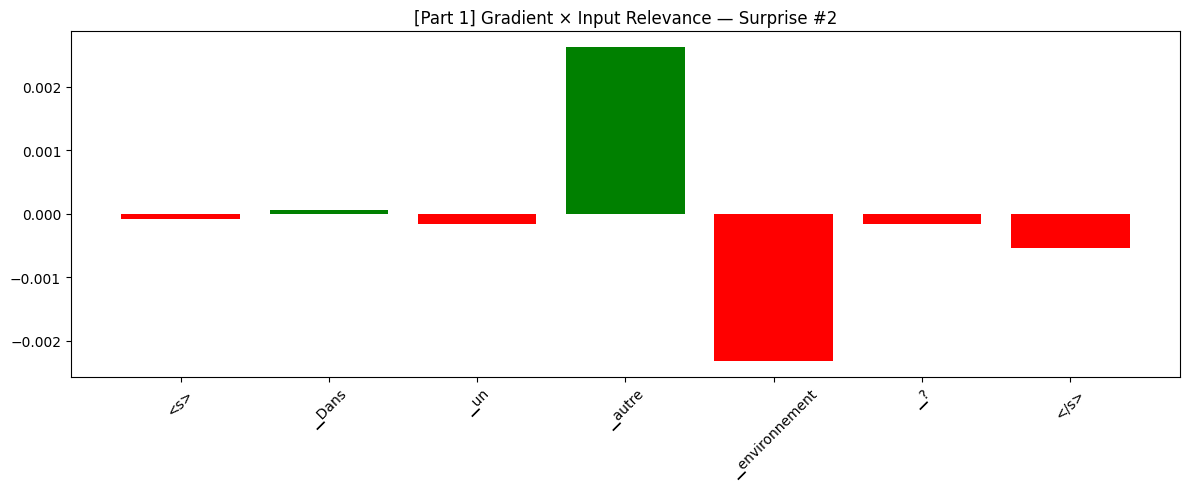

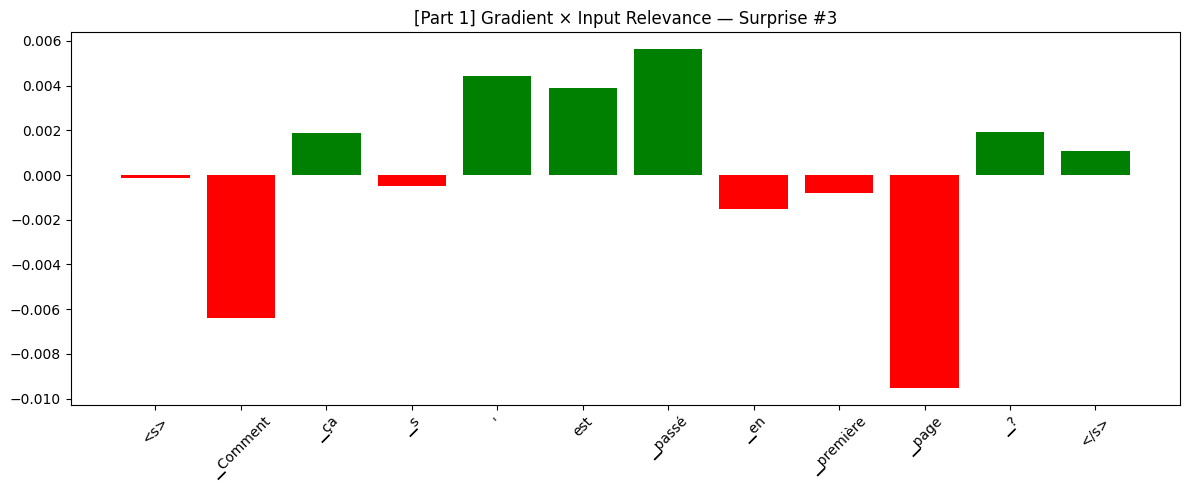

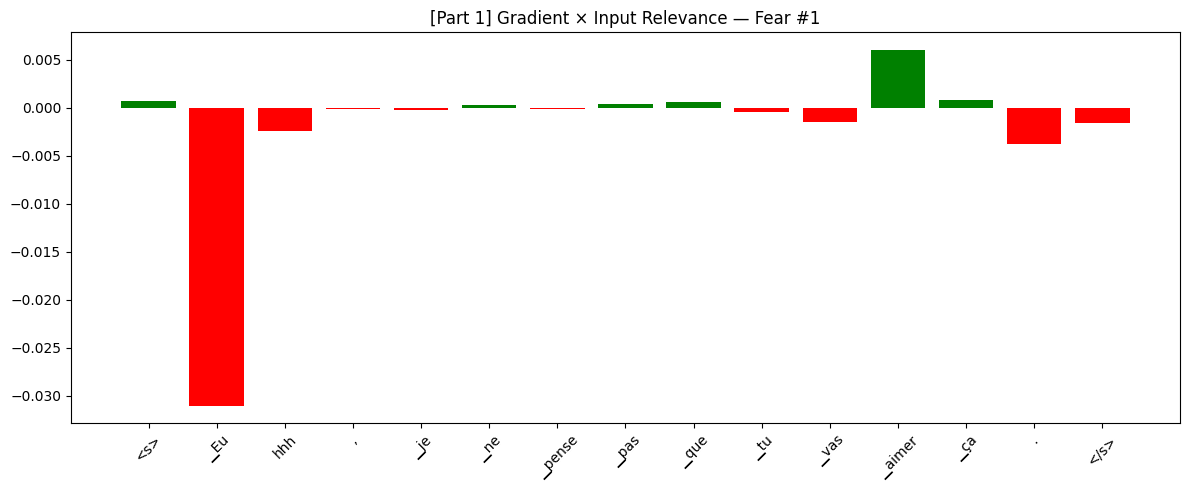

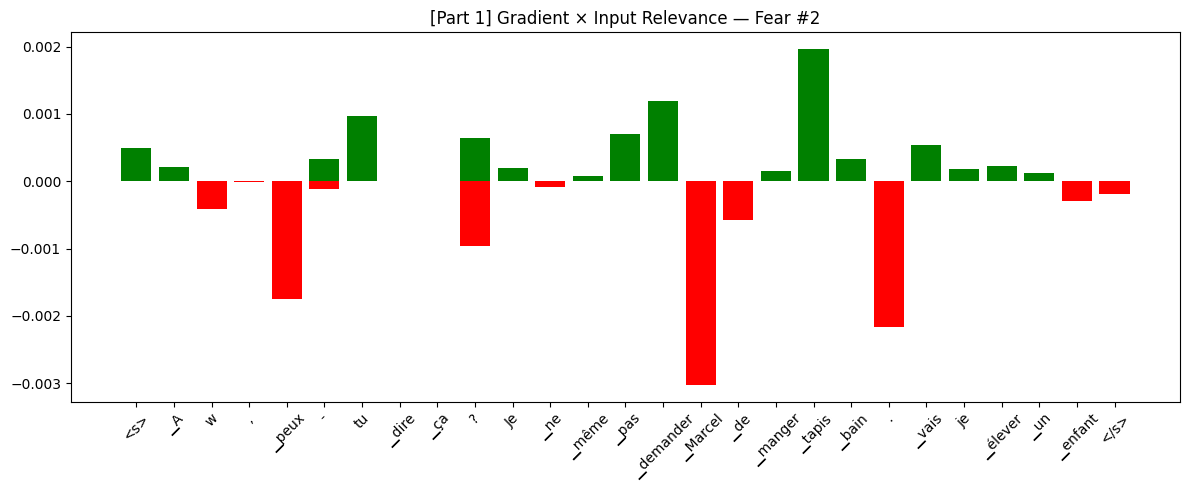

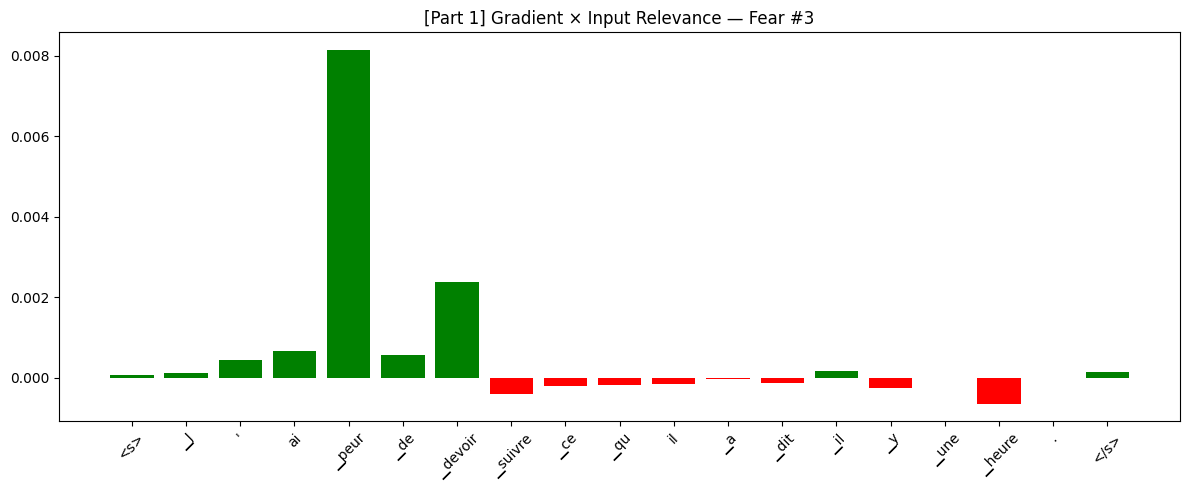

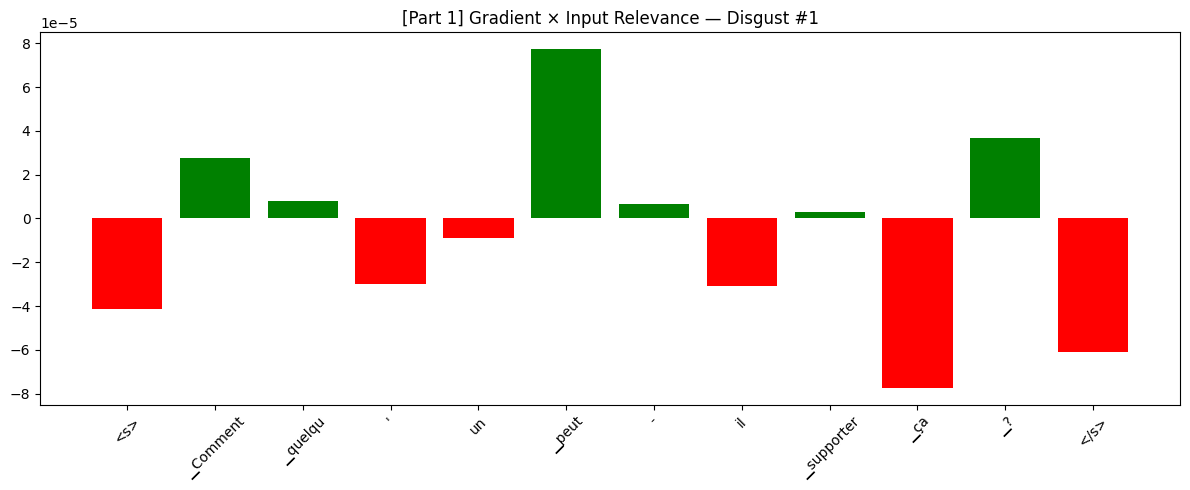

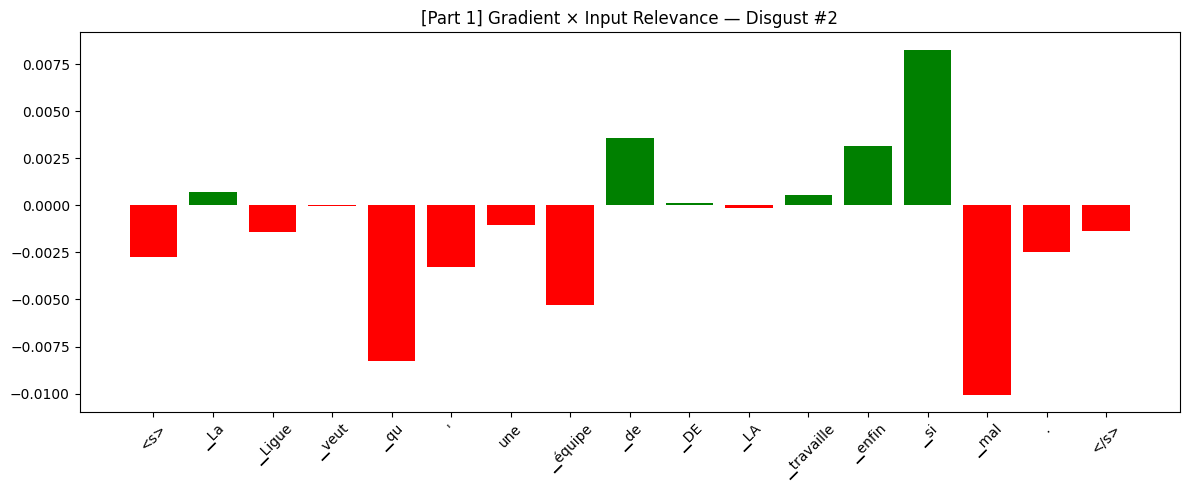

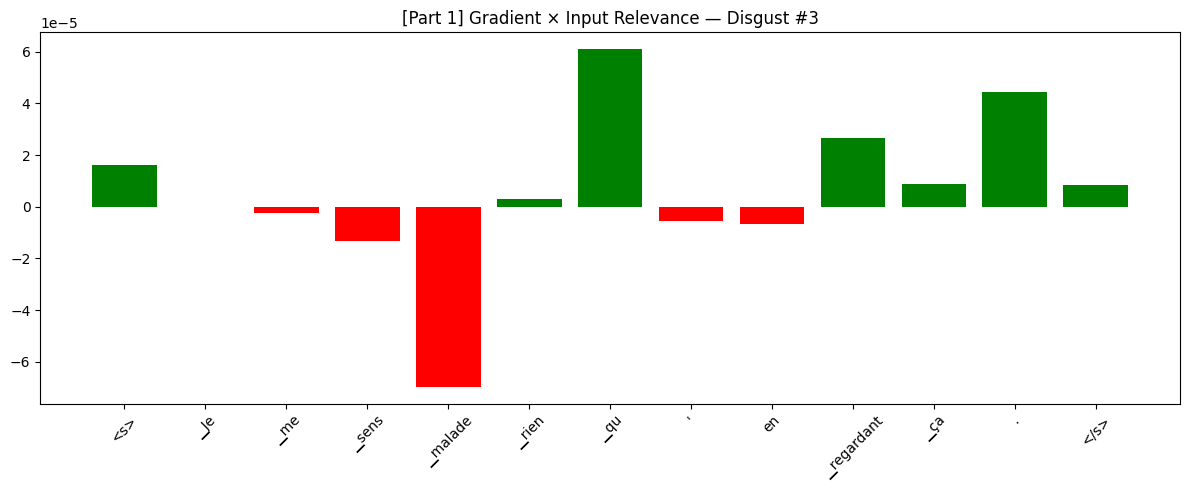

In [5]:
# Create output folder for Part 1 if not exists
output_dir = "outputs/part1_gradient_input(v2)"
os.makedirs(output_dir, exist_ok=True)

# Generate bar graphs for each sentence
for emotion, sentence_list in sentences_by_emotion.items():
    for idx, sentence in enumerate(sentence_list):
        inputs = tokenizer(sentence, return_tensors='pt')
        relevance = gradient_x_input(model, inputs)

        tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
        raw_scores = relevance[0].detach().numpy()
        colors = ['red' if score[0] < 0 else 'green' for score in raw_scores]

        plt.figure(figsize=(12, 5))
        plt.bar(tokens, raw_scores[:, 0], color=colors)
        plt.title(f"[Part 1] Gradient × Input Relevance — {emotion.capitalize()} #{idx+1}")
        plt.xticks(rotation=45)
        plt.tight_layout()

        # Show inline and save to file
        plt.show()
        plt.savefig(f"{output_dir}/{emotion}_{idx+1}.png")
        plt.close()
